# Numerical validation of the model

This notebook compares five configurations of the model:

- baseline: $\Delta t=0.05$, $t_{\mathrm{stab}}=0$, and one deformation attempt;
- $t_{\mathrm{stab}}=120$;
- ten deformation attempts;
- $\Delta t=0.025$;
- triangular initial condition.

The initial goal is to compare the temporal evolution of the simulations.

All time series will be expressed in physical time,

$$
t = n_{\mathrm{step}}\Delta t,
$$

and each realization will be treated as an independent statistical replicate.

## Import libraries

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Load and inspect data

The individual output files were previously consolidated into one Parquet dataset for each simulation condition.

Two datasets are loaded:

- global order parameters;
- motion observables.

The temporal step is converted into physical time using the value of $\Delta t$ associated with each condition.

In [2]:
# Directory containing the five simulation conditions.
DATA_DIR = Path("./validation_data")

conditions = {
    "baseline": {
        "folder": "t_stab=0",
        "delta_t": 0.05,
    },
    "t_stab=120": {
        "folder": "t_stab=120",
        "delta_t": 0.05,
    },
    "def=10": {
        "folder": "def=10",
        "delta_t": 0.05,
    },
    "delta_t=0.025": {
        "folder": "delta_t=0_025",
        "delta_t": 0.025,
    },
    "triangular": {
        "folder": "triangular",
        "delta_t": 0.05,
    },
}

In [3]:
# Define the paths for the processed datasets
PROCESSED_FILES = {
    "order_parameters": (
        Path("processed")
        / "order_parameters"
        / "order_parameters.parquet"
    ),
    "motion": (
        Path("processed")
        / "motion"
        / "motion.parquet"
    ),
}


# Function to load one processed dataset for one simulation condition
def load_processed_dataset(
    data_directory,
    condition_name,
    condition_data,
    dataset_name,
):
    """Load one processed dataset for one simulation condition."""

    parquet_path = (
        data_directory
        / condition_data["folder"]
        / PROCESSED_FILES[dataset_name]
    )

    data = pd.read_parquet(parquet_path).copy()

    # Add the condition name, delta_t, and physical time to the dataset
    data["condition"] = condition_name
    data["delta_t"] = condition_data["delta_t"]
    data["physical_time"] = (
        data["step"] * data["delta_t"]
    )

    return data

In [4]:
# Load order parameters datasets for all simulation conditions
order_data = pd.concat(
    [
        load_processed_dataset(
            DATA_DIR,
            condition_name,
            condition_data,
            "order_parameters",
        )
        for condition_name, condition_data
        in conditions.items()
    ],
    ignore_index=True,
)

In [5]:
# Load motion datasets for all simulation conditions
motion_data = pd.concat(
    [
        load_processed_dataset(
            DATA_DIR,
            condition_name,
            condition_data,
            "motion",
        )
        for condition_name, condition_data
        in conditions.items()
    ],
    ignore_index=True,
)

In [6]:
# Sort the datasets by condition, seed, and physical time
sort_columns = [
    "condition",
    "seed",
    "physical_time",
]

order_data = (
    order_data
    .sort_values(sort_columns)
    .reset_index(drop=True)
)

motion_data = (
    motion_data
    .sort_values(sort_columns)
    .reset_index(drop=True)
)

In [7]:
# Check the columns of the datasets
print("Order-parameter columns:")
print(order_data.columns.tolist())

print("\nMotion columns:")
print(motion_data.columns.tolist())

Order-parameter columns:
['N', 'reference_N', 'actual_N', 'rho', 'actual_rho', 'seed', 'step', 'initial_fraction_elongated', 'force', 'nematic', 'polar', 'nematic_2', 'polar_2', 'fraction_elongated', 'condition', 'delta_t', 'physical_time']

Motion columns:
['N', 'reference_N', 'actual_N', 'rho', 'actual_rho', 'seed', 'step', 'initial_fraction_elongated', 'force', 'mean_step_displacement', 'mean_squared_step_displacement', 'p95_step_displacement', 'msd_t0', 'condition', 'delta_t', 'physical_time']


## Elongated fraction for individual realizations

We first inspect the elongated fraction of every realization separately.

In [8]:
# Define labels and colors for the simulation conditions
condition_labels = {
    "baseline": r"Baseline ($t_{\mathrm{stab}}=0$)",
    "t_stab=120": r"$t_{\mathrm{stab}}=120$",
    "def=10": "10 deformation attempts",
    "delta_t=0.025": r"$\Delta t=0.025$",
    "triangular": "Triangular initial condition",
}

condition_colors = {
    "baseline": "tab:blue",
    "t_stab=120": "tab:orange",
    "def=10": "tab:green",
    "delta_t=0.025": "tab:red",
    "triangular": "tab:purple",
}

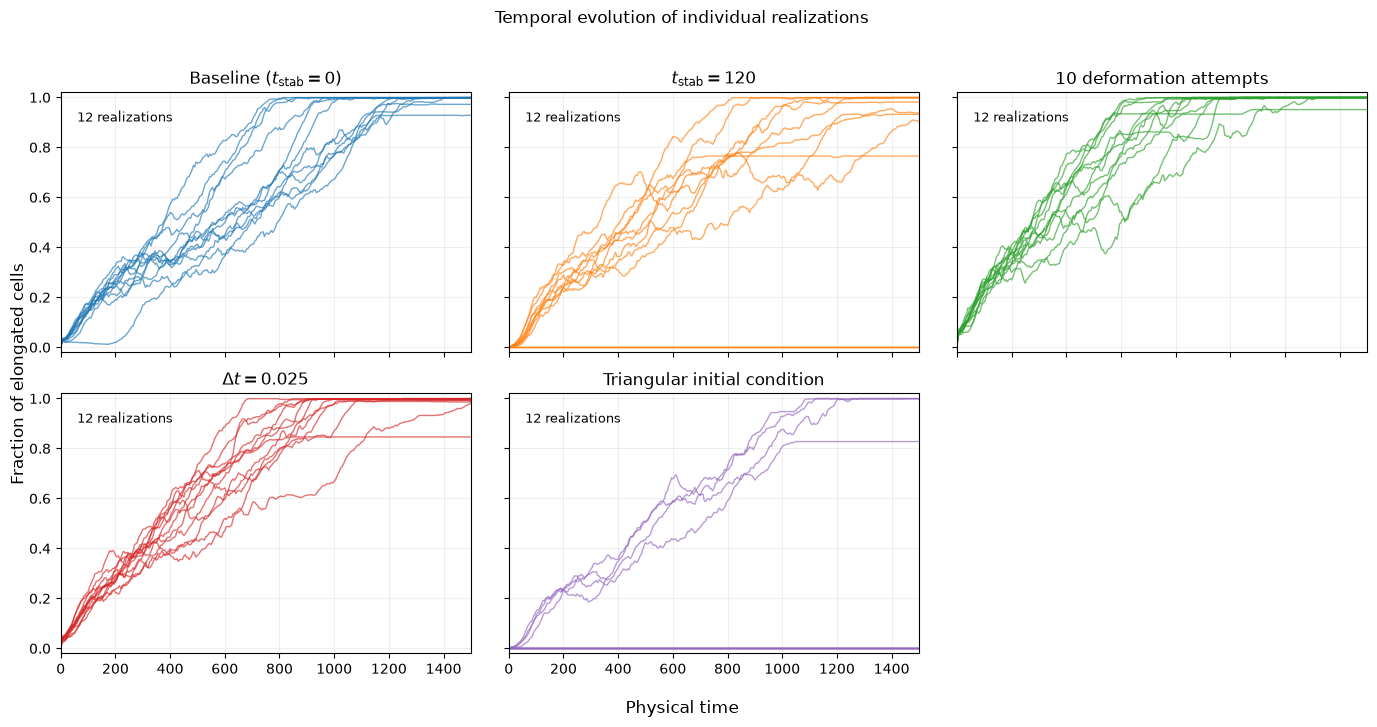

In [9]:
# Create a 2x3 grid of subplots to visualize the temporal evolution of individual realizations
fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(14, 7),
    sharex=True,
    sharey=True,
)

axes = axes.flatten()

# Plot the temporal evolution of individual realizations for each simulation condition
for ax, condition_name in zip(
    axes,
    conditions.keys(),
):
    # Filter the order_data for the current condition
    condition_data = order_data[
        order_data["condition"] == condition_name
    ]

    # Plot the temporal evolution of individual realizations for the current condition
    for seed, realization_data in condition_data.groupby("seed"):

        realization_data = realization_data.sort_values(
            "physical_time"
        )

        ax.plot(
            realization_data["physical_time"],
            realization_data["fraction_elongated"],
            color=condition_colors[condition_name],
            linewidth=1.0,
            alpha=0.65,
        )

    number_of_realizations = (
        condition_data["seed"].nunique()
    )

    ax.set_title(
        condition_labels[condition_name]
    )

    ax.text(
        0.04,
        0.93,
        f"{number_of_realizations} realizations",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
    )

    ax.set_xlim(0, 1500)
    ax.set_ylim(-0.02, 1.02)
    ax.grid(alpha=0.2)

# The sixth panel is not required.
axes[-1].axis("off")

fig.supxlabel("Physical time")
fig.supylabel("Fraction of elongated cells")

fig.suptitle(
    "Temporal evolution of individual realizations",
    y=1.02,
)

fig.tight_layout()

root = Path(".")
folder = root / "figures"
folder.mkdir(parents=True, exist_ok=True)
plt.savefig(
    root / folder / "temporal_evolution_individual_realizations.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## Final-branch occupancy

The individual trajectories reveal two qualitatively different outcomes:

- realizations that remain in the completely round state;
- realizations that activate the elongated branch.

To quantify this behavior, each realization is characterized by its mean elongated fraction during the final time window, $1200 \leq t \leq 1500$.

The activation threshold introduced below is only used to distinguish the exactly round trajectories from the active trajectories. It is not intended to define a critical point.

In [10]:
# Compute the final state of the system for each simulation condition and realization
FINAL_WINDOW_START = 1200.0
ACTIVATION_THRESHOLD = 0.1

# Compute the final state of the system for each simulation condition and realization
final_state_data = (
    order_data[
        order_data["physical_time"] >= FINAL_WINDOW_START
    ]
    .groupby(
        ["condition", "seed"],
        as_index=False,
    )
    .agg(
        final_fraction_elongated=(
            "fraction_elongated",
            "mean",
        )
    )
)

# Determine whether each realization is activated based on the final fraction of elongated cells
final_state_data["activated"] = (
    final_state_data["final_fraction_elongated"]
    > ACTIVATION_THRESHOLD
)

In [11]:
# Summarize the activation results for each simulation condition
activation_summary = (
    final_state_data
    .groupby("condition")
    .agg(
        number_of_realizations=("seed", "size"),
        number_activated=("activated", "sum"),
        activation_probability=("activated", "mean"),
    )
    .reindex(conditions.keys())
)

activation_summary

,number_of_realizations,number_activated,activation_probability
condition,,,
baseline,12,12,1.000000
t_stab=120,12,9,0.750000
def=10,12,12,1.000000
delta_t=0.025,12,12,1.000000
triangular,12,4,0.333333


## Temporal evolution of the two dynamical branches

The overall average combines two effects:

1. the probability that a realization activates the elongated branch;
2. the temporal evolution after activation.

To separate these contributions, we compare the mean elongated fraction using:

- all realizations;
- only realizations that belong to the activated final branch.

The shaded regions represent one standard deviation across realizations.

In [12]:
# Merge the final state data with the order_data to include the activation status for each realization
order_data_with_branch = order_data.merge(
    final_state_data[
        [
            "condition",
            "seed",
            "activated",
        ]
    ],
    on=[
        "condition",
        "seed",
    ],
    how="left",
    validate="many_to_one",
)

In [13]:
# Function to summarize the time series data by calculating the mean and standard deviation 
# at each physical time
def summarize_time_series(
    data,
    observable,
):
    """Calculate the mean and standard deviation at each physical time."""

    summary = (
        data
        .groupby(
            [
                "condition",
                "physical_time",
            ],
            as_index=False,
        )
        .agg(
            mean=(observable, "mean"),
            standard_deviation=(observable, "std"),
            number_of_realizations=(observable, "count"),
        )
    )

    summary["standard_deviation"] = (
        summary["standard_deviation"].fillna(0)
    )

    return summary

In [14]:
# Summarize the time series data for all realizations and for activated realizations
fraction_all = summarize_time_series(
    order_data_with_branch,
    "fraction_elongated",
)

fraction_activated = summarize_time_series(
    order_data_with_branch[
        order_data_with_branch["activated"]
    ],
    "fraction_elongated",
)

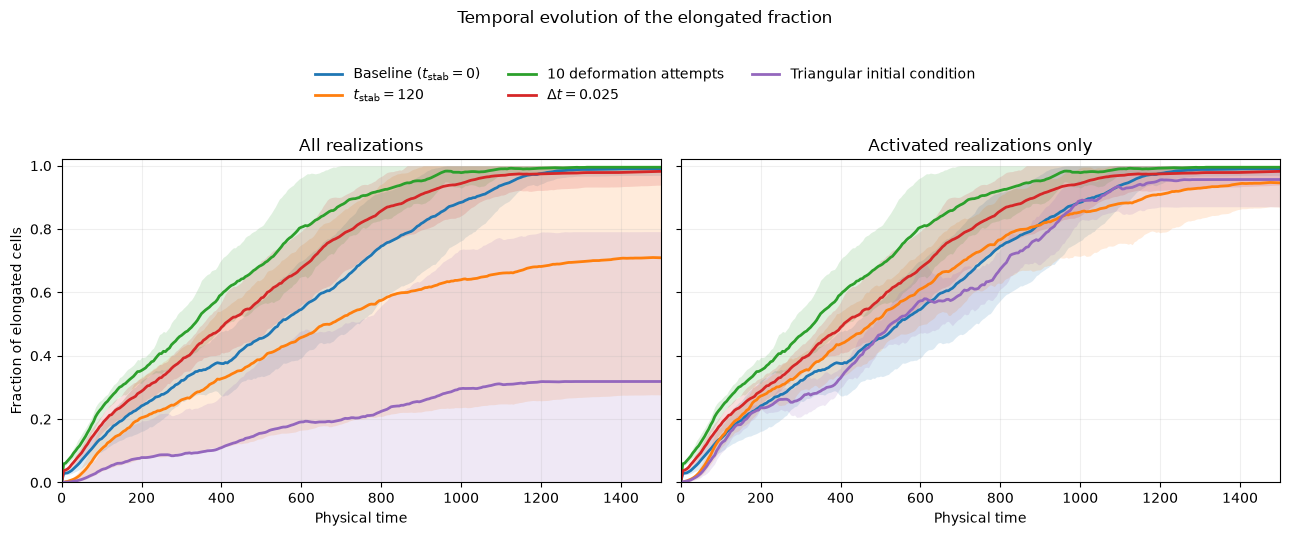

In [16]:
# Create a 1x2 grid of subplots to visualize the temporal evolution of the elongated fraction
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(13, 4.5),
    sharex=True,
    sharey=True,
)

# Define the summaries and titles for the two subplots
summaries = [
    (
        fraction_all,
        "All realizations",
    ),
    (
        fraction_activated,
        "Activated realizations only",
    ),
]

# Plot the temporal evolution of the elongated fraction for each simulation condition
for ax, (summary, title) in zip(
    axes,
    summaries,
):
    for condition_name in conditions:

        condition_summary = summary[
            summary["condition"] == condition_name
        ].sort_values("physical_time")

        time = condition_summary[
            "physical_time"
        ].to_numpy()

        mean = condition_summary[
            "mean"
        ].to_numpy()

        standard_deviation = condition_summary[
            "standard_deviation"
        ].to_numpy()

        # Calculate the lower and upper bounds for the shaded area representing the standard deviation
        lower_bound = np.clip(
            mean - standard_deviation,
            0,
            1,
        )

        upper_bound = np.clip(
            mean + standard_deviation,
            0,
            1,
        )

        ax.plot(
            time,
            mean,
            color=condition_colors[condition_name],
            linewidth=2,
            label=condition_labels[condition_name],
        )

        ax.fill_between(
            time,
            lower_bound,
            upper_bound,
            color=condition_colors[condition_name],
            alpha=0.15,
            linewidth=0,
        )

    ax.set_title(title)
    ax.set_xlim(0, 1500)
    ax.set_ylim(0, 1.02)
    ax.set_xlabel("Physical time")
    ax.grid(alpha=0.2)

axes[0].set_ylabel("Fraction of elongated cells")

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncols=3,
    frameon=False,
)

fig.suptitle(
    "Temporal evolution of the elongated fraction",
    y=1.18,
)

fig.tight_layout()

root = Path(".")
folder = root / "figures"
folder.mkdir(parents=True, exist_ok=True)
plt.savefig(
    root / folder / "temporal_evolution_elongated_fraction.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## Population-weighted orientational order

The orientational order parameters `nematic` and `polar` are calculated among elongated cells.

To characterize the complete population, we use the weighted quantities

$$
Q_{\mathrm{weighted}} = f_E Q,
$$

and

$$
P_{\mathrm{weighted}} = f_E P.
$$

As for the elongated fraction, the temporal evolution is shown using both all realizations and only the realizations that reach the activated branch.

In [17]:
# Define the observables and branch selections for further analysis
observables = [
    {
        "column": "nematic_2",
        "label": r"Weighted nematic order $f_E Q$",
    },
    {
        "column": "polar_2",
        "label": r"Weighted polar order $f_E P$",
    },
]

branch_selections = [
    {
        "title": "All realizations",
        "data": order_data_with_branch,
    },
    {
        "title": "Activated realizations only",
        "data": order_data_with_branch[
            order_data_with_branch["activated"]
        ],
    },
]

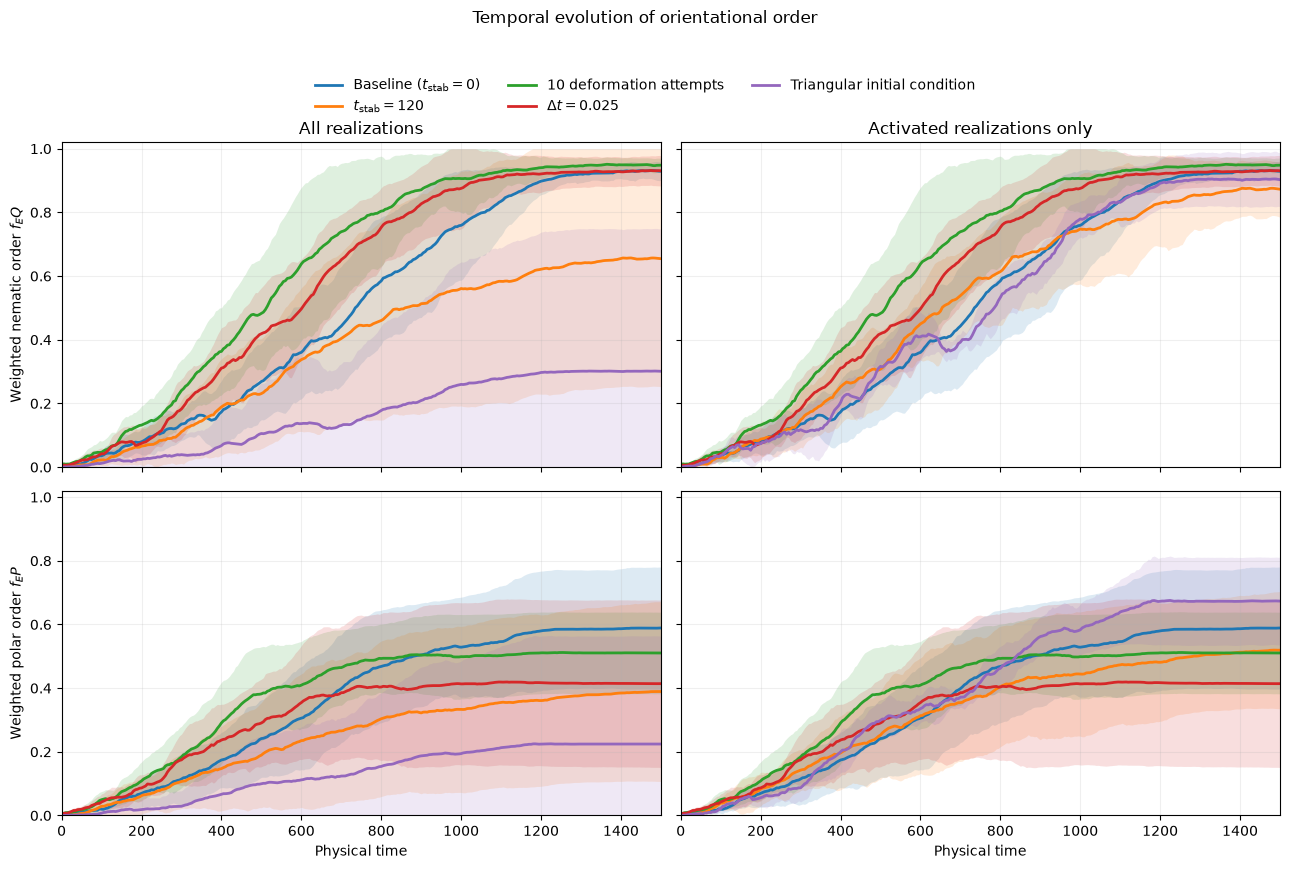

In [19]:
# Create a 2x2 grid of subplots to visualize the temporal evolution of the 
# weighted nematic and polar order parameters
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(13, 8),
    sharex=True,
    sharey="row",
)

# Plot the temporal evolution of the weighted nematic and polar order 
# parameters for each simulation condition and branch selection
for row, observable_data in enumerate(observables):

    for column, branch_data in enumerate(
        branch_selections
    ):

        ax = axes[row, column]

        summary = summarize_time_series(
            branch_data["data"],
            observable_data["column"],
        )

        for condition_name in conditions:

            condition_summary = summary[
                summary["condition"] == condition_name
            ].sort_values("physical_time")

            time = condition_summary[
                "physical_time"
            ].to_numpy()

            mean = condition_summary[
                "mean"
            ].to_numpy()

            standard_deviation = condition_summary[
                "standard_deviation"
            ].to_numpy()

            # Calculate the lower and upper bounds for the shaded area representing the standard deviation
            lower_bound = np.clip(
                mean - standard_deviation,
                0,
                1,
            )

            upper_bound = np.clip(
                mean + standard_deviation,
                0,
                1,
            )

            ax.plot(
                time,
                mean,
                color=condition_colors[condition_name],
                linewidth=2,
                label=condition_labels[condition_name],
            )

            ax.fill_between(
                time,
                lower_bound,
                upper_bound,
                color=condition_colors[condition_name],
                alpha=0.15,
                linewidth=0,
            )

        if row == 0:
            ax.set_title(
                branch_data["title"]
            )

        if column == 0:
            ax.set_ylabel(
                observable_data["label"]
            )

        if row == 1:
            ax.set_xlabel("Physical time")

        ax.set_xlim(0, 1500)
        ax.set_ylim(0, 1.02)
        ax.grid(alpha=0.2)

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.01),
    ncols=3,
    frameon=False,
)

fig.suptitle(
    "Temporal evolution of orientational order",
    y=1.08,
)

fig.tight_layout()

root = Path(".")
folder = root / "figures"
folder.mkdir(parents=True, exist_ok=True)
plt.savefig(
    root / folder / "temporal_evolution_orientational_order.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()